<a href="https://colab.research.google.com/github/8JorgeAquino8/Analisis-de-riesgo-en-grafo/blob/main/analisisGrafoDatos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pulp
!pip install networkx
!pip install matplotlib

In [ ]:
from numpy._core.defchararray import index
import pandas as pd
ruta = '/content/interval_risk_adjacency_matrices_all.xlsx'
df = pd.read_excel(ruta, sheet_name='Opt_20', index_col=0)

In [ ]:
import networkx as nx
Grafo1 = nx.DiGraph()
for i in df.index:
  for j in df.columns:
    peso = df.loc[i,j]
    if pd.notna(peso) and peso != 0:
      Grafo1.add_edge(i, j, weight=peso)

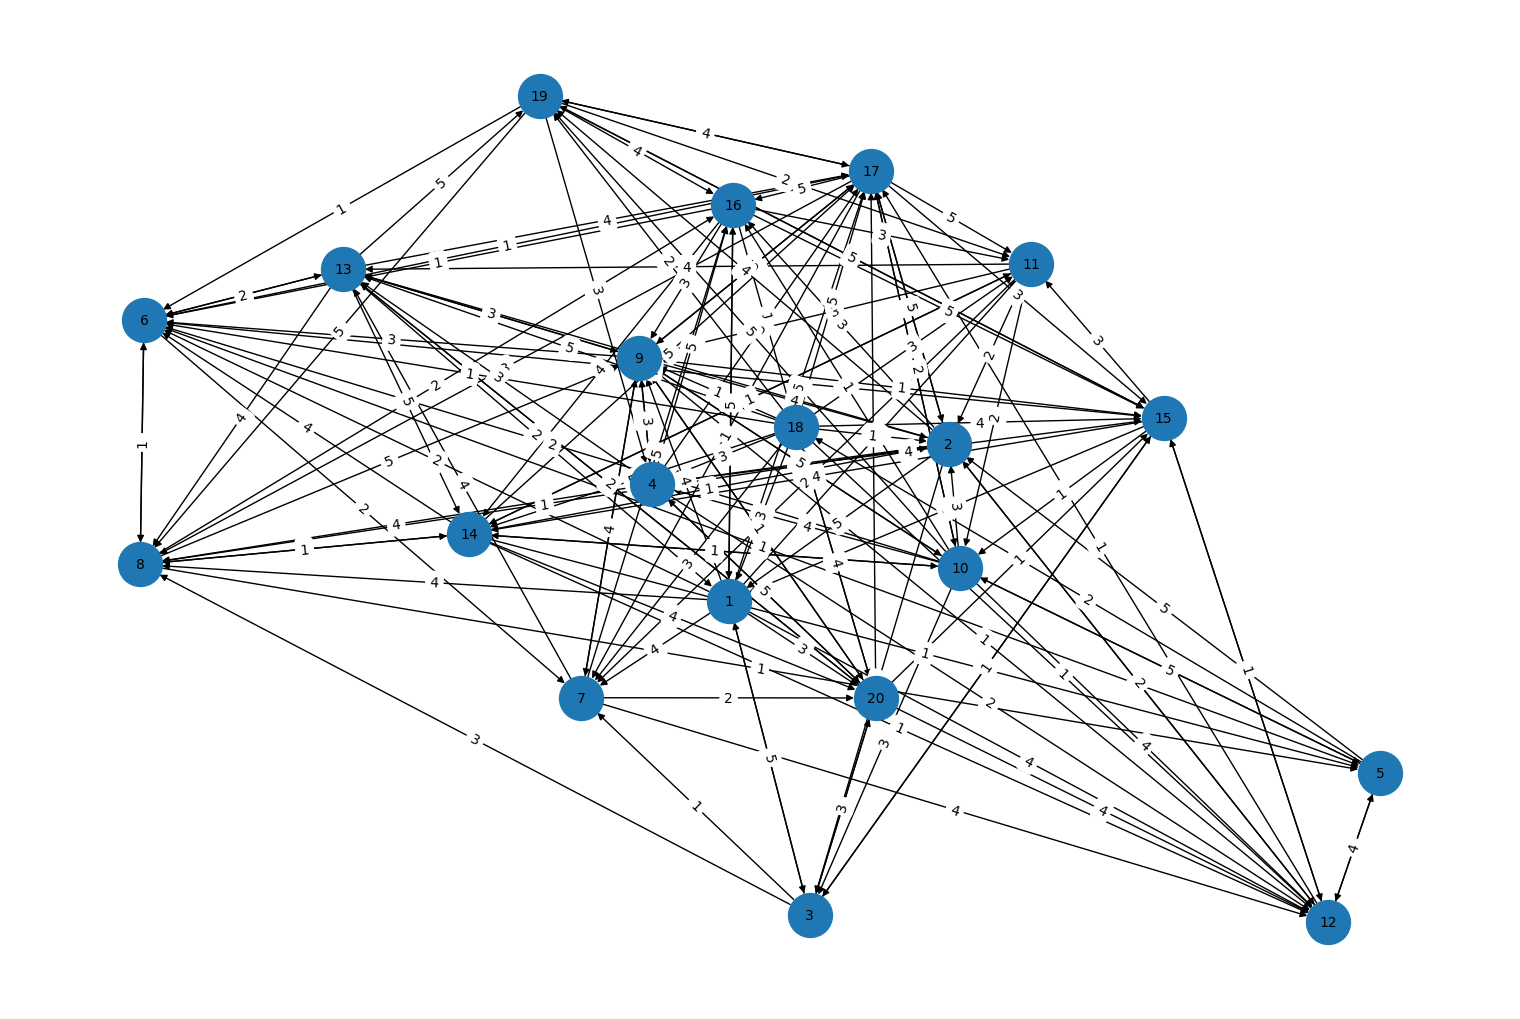

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
pos =nx.spring_layout(Grafo1)
nx.draw(Grafo1, pos, with_labels=True, node_size=1000, font_size=10)
nx.draw_networkx_edge_labels(Grafo1, pos, edge_labels=nx.get_edge_attributes(Grafo1, 'weight'))
plt.show()

In [ ]:
def dijkstra_k(G, s, t, K): #dijkstra con maximo k saltos
  lista = [(0, s, 0, [t])]
  dist={}
  prev={}
  for nodo in G.nodes():
    for k in range(K+1):
      dist[(nodo, k)] = float('inf')
  dist[(s,0)] = 0
  Q = [(s,0)]

  while Q:
    actual = min(Q, key=lambda x: dist[x])
    Q.remove(actual)
    nodo , pasos = actual
    if nodo == t:
      break
    if pasos == K:
      continue
    for vecino in G.neighbors(nodo):
      peso = G[nodo][vecino]['weight']

      nuevo_estado = (vecino, pasos+1)
      nuevo_costo = dist[(nodo,pasos)] + peso

      if nuevo_costo < dist[nuevo_estado]:
        dist[nuevo_estado] = nuevo_costo
        prev[nuevo_estado] = (nodo, pasos)
        if nuevo_estado not in Q:
          Q.append(nuevo_estado)

  mejor_costo = float('inf')
  mejor_estado = None

  for k in range(K+1):
    if dist[(t,k)] < mejor_costo:
      mejor_costo = dist[(t,k)]
      mejor_estado = (t,k)

  if mejor_estado is None:
    return None, float('inf')

  camino = []
  actual  = mejor_estado

  while actual in prev:
    nodo, _ = actual
    camino.append(nodo)
    actual = prev[actual]

  camino.append(s)
  camino.reverse()

  return camino, mejor_costo

In [ ]:
#nodos que usaremos para nuestro ejemplo
a = 1
b = 13

In [ ]:
camino, costo = dijkstra_k(Grafo1, a, b, 4)
print(camino)
print(costo)

[1, 9, 13]
5


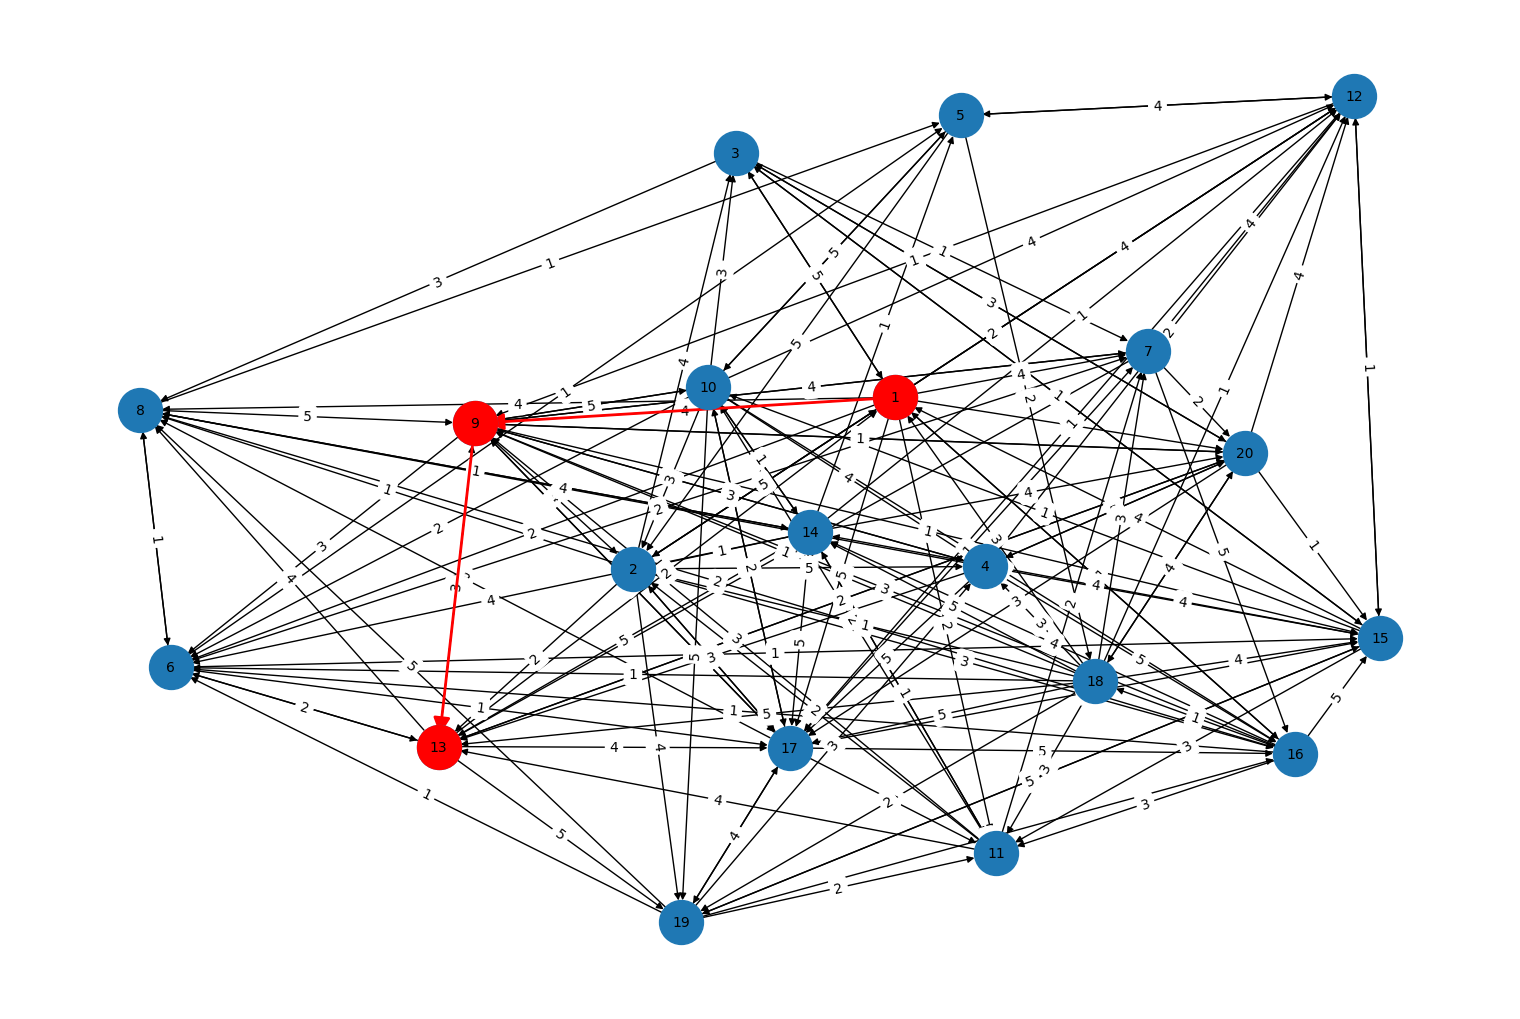

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,10))
pos =nx.spring_layout(Grafo1)
nx.draw(Grafo1, pos, with_labels=True, node_size=1000, font_size=10)
nx.draw_networkx_edge_labels(Grafo1, pos, edge_labels=nx.get_edge_attributes(Grafo1, 'weight'))
nx.draw_networkx_nodes(Grafo1, pos, nodelist=camino, node_color='r', node_size=1000)
nx.draw_networkx_edges(Grafo1, pos, edgelist=list(zip(camino, camino[1:])), edge_color='r', width=2, arrows=True, arrowsize=25)
plt.show()

In [ ]:
dfopt = df
dfpes = pd.read_excel(ruta, sheet_name='Pes_20', index_col=0)

In [ ]:
G_opt = Grafo1
G_pes = nx.DiGraph()

for i in dfpes.index:
  for j in dfpes.columns:
    peso = dfpes.loc[i,j]
    if pd.notna(peso) and peso != 0:
      G_pes.add_edge(i, j, weight=peso)

In [ ]:
G_medio =  nx.DiGraph()

for i in df.index:
  for j in df.columns:
    popt = dfopt.loc[i,j]
    ppes = dfpes.loc[i,j]
    if pd.notna(popt) and pd.notna(ppes) and popt != 0 and ppes != 0:
      G_medio.add_edge(i, j, weight=popt+ppes/2)

In [ ]:
camino_costo_medio, costo_costo_medio = dijkstra_k(G_medio, a, b, 4)
print('El mejor camino usando costo medio es: ', camino_costo_medio)
print(' y tiene un costo de: ',costo_costo_medio)

El mejor camino usando costo medio es:  [1, 6, 13]
 y tiene un costo de:  15.0


In [ ]:
camino_opt, costo_opt = dijkstra_k(G_opt, a, b, 4)
print('El mejor camino usando costo optimista: ', camino_opt)
print(' y tiene un costo de: ',costo_opt)

El mejor camino usando costo optimista:  [1, 9, 13]
 y tiene un costo de:  5


In [ ]:
camino_pes, costo_pes = dijkstra_k(G_pes, a, b, 4)
print('El mejor camino usando costo pesimista: ', camino_pes)
print(' y tiene un costo de: ',costo_pes)

El mejor camino usando costo pesimista:  [1, 6, 13]
 y tiene un costo de:  16


In [ ]:
def costo_camino(G,camino):
  peso = 0
  for i in range(len(camino)-1):
    peso += G[camino[i]][camino[i+1]]['weight']
  return peso


In [ ]:
#evaluamos el camino obtenido del grafo optimista en el pesimista y viceversa
print('Costo del camino optimista evaluado en el grafo pesimista: \n',costo_camino(G_pes,camino_opt))
print('Costo del camino pesimista evaluado en el grafo otimista: \n',costo_camino(G_opt,camino_pes))

Costo del camino optimista evaluado en el grafo pesimista: 
 24
Costo del camino pesimista evaluado en el grafo otimista: 
 7


In [ ]:
def arrepentimiento(G,camino,otro):
  return (costo_camino(G,camino)-min(costo_camino(G,camino), costo_camino(G,otro)))

In [ ]:
def minimax_arrepentimiento(Gopt,Gpes,camino,otro):
  x=arrepentimiento(Gopt,camino,otro)
  y=arrepentimiento(Gpes,camino,otro)
  return max(x,y)

In [ ]:
a_opt = minimax_arrepentimiento(G_opt,G_pes,camino_opt, camino_pes)
a_pes = minimax_arrepentimiento(G_pes,G_opt,camino_pes, camino_opt)
print(a_opt)
print(a_pes)
#

8
2


In [ ]:
def a_esp(Gopt,Gpes,camino,otro):
  x=arrepentimiento(Gopt,camino,otro)
  y=arrepentimiento(Gpes,camino,otro)
  return 0.5*(x+y)

In [ ]:
print('El arrepentimiento esperado del camino optimista es: \n',a_esp(G_opt,G_pes,camino_opt, camino_pes))
print("El arrepentimiento esperado del camino pesimista es: \n",a_esp(G_pes,G_opt,camino_pes, camino_opt))

El arrepentimiento esperado del camino optimista es: 
 4.0
El arrepentimiento esperado del camino pesimista es: 
 1.0
